# Baseline: End-to-End Steering & Speed Prediction
Train a simple CNN to predict steering angle and speed from image frames + CAN data.  

---
### Pipeline Overview
```
Image Frame (64×64)  ──┐
                         ├──► CNN + MLP ──► [speed_pred, steer_pred]
CAN (speed, steer now) ──┘
```

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

## 0. Setup & Installs
```bash
pip install torch torchvision opencv-python matplotlib tqdm
```

In [ ]:
import sys
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, IterableDataset
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

sys.path.insert(0, str(Path.cwd()))
from data_loader import Comma_Segment
print('data_loader imported successfully')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

data_loader imported successfully
Using device: cpu


## 1. Config — Edit paths and hyperparameters here

In [ ]:

CHUNK_PATH = Path('data_utils/comma2k19_data/extracted/Chunk_1')
SAVE_DIR   = Path('.')   

IMG_SIZE    = (64, 64)    # use CPU to train so set the size smaller
FUTURE_TIME = 1.0         # predict 1 second into the future
TRAIN_SPLIT = 0.8         # 80% train 20% val
BATCH_SIZE  = 16          
NUM_EPOCHS  = 10
LR          = 1e-3
NUM_WORKERS = 0         
QUICK_TEST  = False       #QUICK TEST mode: only use first 5 segment (debug usage)

print('Config loaded.')
print(f'  Image size  : {IMG_SIZE}')
print(f'  Batch size  : {BATCH_SIZE}')
print(f'  Epochs      : {NUM_EPOCHS}')
print(f'  Device      : {device}')
print(f'  Quick test  : {QUICK_TEST}')
print(f'  Chunk path  : {CHUNK_PATH.resolve()}')
print(f'  Path exists : {CHUNK_PATH.exists()}')


Config loaded.
  Image size  : (64, 64)
  Batch size  : 16
  Epochs      : 10
  Device      : cpu
  Quick test  : False
  Chunk path  : C:\Users\User\Desktop\碩士要加油\26spring\228\project_upload\comma2k19_FSD-main\data_utils\comma2k19_data\extracted\Chunk_1
  Path exists : True


## 2. Dataset — Train / Val Split

In [ ]:
class SplitDataset(IterableDataset):
    """
    Wraps Comma_Segment and splits by segment paths.
    IterableDataset doesn't support random index splits,
    so we split the segment list before iterating.
    """
    def __init__(self, segment_paths, target_size=(64, 64), future_time=1.0):
        self.segment_paths = segment_paths
        self.target_size   = target_size
        self.future_time   = future_time

    def _load_frames(self, segment):
        cap    = cv2.VideoCapture(segment.video_path)
        frames = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frames.append(segment.preprocess_frame(frame))
        cap.release()
        return frames

    def __iter__(self):
        for seg_path in self.segment_paths:
            try:
                segment      = Comma_Segment(seg_path, self.target_size)
                max_can_time = min(segment.speed_t[-1], segment.steer_t[-1])
                frames       = self._load_frames(segment)

                for frame_idx, frame in enumerate(frames):
                    t_cur    = segment.frame_times[frame_idx]
                    t_future = t_cur + self.future_time
                    if t_future > max_can_time:
                        continue
                    # concat previous 3 frame
                    f0 = frames[max(0, frame_idx - 2)]
                    f1 = frames[max(0, frame_idx - 1)]
                    f2 = frames[frame_idx]
                    stacked = np.concatenate([f0, f1, f2], axis=2)
                    # concat previous 3 CAN data
                    t0 = segment.frame_times[max(0, frame_idx - 2)]
                    t1 = segment.frame_times[max(0, frame_idx - 1)]
                    x_speed_0, x_steer_0 = segment.get_CAN_data(t0)
                    x_speed_1, x_steer_1 = segment.get_CAN_data(t1)
                    x_speed_2, x_steer_2 = segment.get_CAN_data(t_cur)

                    y_speed, y_steer = segment.get_CAN_data(t_future)

                    yield {
                        'x_frame': torch.from_numpy(stacked).permute(2, 0, 1).float() / 255.0,
                        'x_speed': torch.tensor([x_speed_0, x_speed_1, x_speed_2], dtype=torch.float32),
                        'x_steer': torch.tensor([x_steer_0, x_steer_1, x_steer_2], dtype=torch.float32),
                        'y_speed': torch.tensor(y_speed, dtype=torch.float32),
                        'y_steer': torch.tensor(y_steer, dtype=torch.float32),
                    }
                del frames

            except Exception as e:
                print(f'  [skip] {seg_path.name}: {e}')
                continue

all_segments = []
for drive_folder in sorted(CHUNK_PATH.iterdir()):
    if drive_folder.is_dir():
        for seg in sorted(drive_folder.iterdir(),
                          key=lambda x: int(x.name) if x.name.isdigit() else x.name):
            if seg.is_dir():
                all_segments.append(seg)

if QUICK_TEST:
    all_segments = all_segments[:5]
    print('Quick test mode: using only first 5 segments')

split_idx      = int(len(all_segments) * TRAIN_SPLIT)
train_segments = all_segments[:split_idx]
val_segments   = all_segments[split_idx:]

print(f'Total segments : {len(all_segments)}')
print(f'Train segments : {len(train_segments)}')
print(f'Val   segments : {len(val_segments)}')

train_loader = DataLoader(SplitDataset(train_segments, IMG_SIZE, FUTURE_TIME),
                          batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)
val_loader   = DataLoader(SplitDataset(val_segments,   IMG_SIZE, FUTURE_TIME),
                          batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)
print('Dataloaders ready.')


Total segments : 188
Train segments : 150
Val   segments : 38
Dataloaders ready.


## 3. Model — Simple CNN Baseline

```
Image ──► Conv×4 + BN + ReLU + MaxPool ──► Flatten ──┐
                                                     ├──► Linear×3 ──► [speed, steer]
CAN (current speed, steer) ──────────────────────────┘
```

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self, img_size=64):
        super().__init__()

        # CNN: 9 channels (3 frame * RGB)
        self.cnn = nn.Sequential(
            nn.Conv2d(9,   16, 3, padding=1), nn.BatchNorm2d(16),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16,  32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,  64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        cnn_out = 128 * (img_size // 16) ** 2  

        # MLP: fuse CNN features + previous 3 CAN (speed*3 + steer*3 = 6)
        self.mlp = nn.Sequential(
            nn.Linear(cnn_out + 6, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 64),          nn.ReLU(),
            nn.Linear(64, 2),            # speed_pred, steer_pred
        )

    def forward(self, frame, speed, steer):
        x   = self.cnn(frame).flatten(1)
        can = torch.cat([speed, steer], dim=1)  
        return self.mlp(torch.cat([x, can], dim=1))


model = BaselineCNN(img_size=IMG_SIZE[0]).to(device)

with torch.no_grad():
    out = model(torch.randn(2, 9, *IMG_SIZE).to(device),
                torch.randn(2, 3).to(device),
                torch.randn(2, 3).to(device))
print(f'Output shape : {out.shape}')   # (2, 2)
print(f'Parameters   : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


Output shape : torch.Size([2, 2])
Parameters   : 641,442


## 4. Loss Function
Speed (0–35 m/s) and steering (−30 to +30 deg) have different scales.  
We normalise each independently so neither dominates the loss.

In [6]:
SPEED_SCALE = 30.0
STEER_SCALE = 30.0

def normalised_mse(pred, y_speed, y_steer):
    loss_spd = nn.functional.mse_loss(pred[:, 0] / SPEED_SCALE, y_speed / SPEED_SCALE)
    loss_str = nn.functional.mse_loss(pred[:, 1] / STEER_SCALE, y_steer / STEER_SCALE)
    return loss_spd + loss_str

optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
print('Loss and optimiser ready.')

Loss and optimiser ready.


## 5. Training Loop

In [7]:
history = dict(train_loss=[], val_loss=[],
               train_speed_mae=[], train_steer_mae=[],
               val_speed_mae=[],   val_steer_mae=[])


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = speed_mae = steer_mae = n = 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in tqdm(loader, desc='train' if train else 'val  ', leave=False):
            frame   = batch['x_frame'].to(device)
            x_speed = batch['x_speed'].to(device)
            x_steer = batch['x_steer'].to(device)
            y_speed = batch['y_speed'].to(device)
            y_steer = batch['y_steer'].to(device)

            pred = model(frame, x_speed, x_steer)
            loss = normalised_mse(pred, y_speed, y_steer)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            bs          = frame.size(0)
            total_loss += loss.item() * bs
            speed_mae  += torch.abs(pred[:, 0] - y_speed).sum().item()
            steer_mae  += torch.abs(pred[:, 1] - y_steer).sum().item()
            n          += bs

    return total_loss / n, speed_mae / n, steer_mae / n


print('Starting training...\n')
best_val = float('inf')

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_sp, tr_st = run_epoch(train_loader, train=True)
    vl_loss, vl_sp, vl_st = run_epoch(val_loader,   train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_speed_mae'].append(tr_sp)
    history['train_steer_mae'].append(tr_st)
    history['val_speed_mae'].append(vl_sp)
    history['val_steer_mae'].append(vl_st)

    flag = ''
    if vl_loss < best_val:
        best_val = vl_loss
        torch.save(model.state_dict(), SAVE_DIR / 'baseline_best.pth')
        flag = ' saved'

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
          f'loss {tr_loss:.4f}/{vl_loss:.4f} | '
          f'speed MAE {vl_sp:.2f} m/s | steer MAE {vl_st:.2f} deg | '
          f'{time.time()-t0:.0f}s{flag}')

print('\nTraining complete!')

Starting training...



Epoch 01/10 | loss 0.1559/0.2423 | speed MAE 5.16 m/s | steer MAE 4.24 deg | 3193s saved


Epoch 02/10 | loss 0.1267/0.2219 | speed MAE 5.18 m/s | steer MAE 3.97 deg | 3257s saved


Epoch 03/10 | loss 0.1329/0.2292 | speed MAE 5.00 m/s | steer MAE 3.98 deg | 3523s


Epoch 04/10 | loss 0.1277/0.2464 | speed MAE 5.16 m/s | steer MAE 4.01 deg | 3392s


...

Epoch 06/10 | loss 0.1107/0.2271 | speed MAE 5.17 m/s | steer MAE 3.82 deg | 3702s


Epoch 07/10 | loss 0.1051/0.2249 | speed MAE 5.26 m/s | steer MAE 3.75 deg | 3467s


Epoch 08/10 | loss 0.1043/0.2214 | speed MAE 5.25 m/s | steer MAE 3.71 deg | 3601s saved


Epoch 09/10 | loss 0.1050/0.2212 | speed MAE 5.08 m/s | steer MAE 3.88 deg | 3537s saved


Epoch 10/10 | loss 0.0979/0.2137 | speed MAE 4.96 m/s | steer MAE 3.90 deg | 2481s saved

Training complete!


In [ ]:
import json
with open(SAVE_DIR / 'history.json', 'w') as f:
    json.dump(history, f)
print('History saved to history.json')


History saved to history.json


## 6. Training Curves

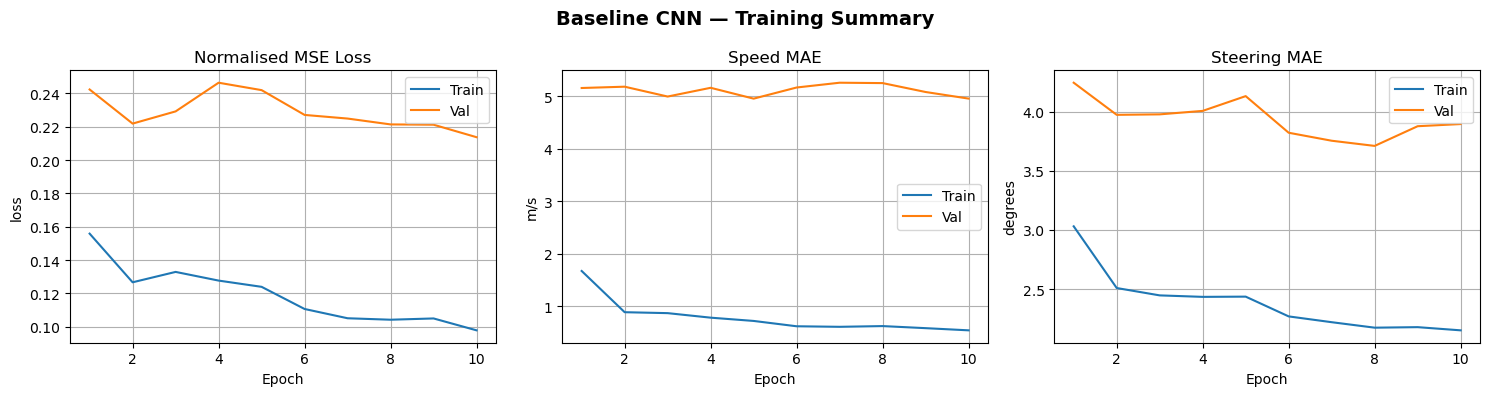

Plot saved.


In [9]:
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, key_tr, key_vl, title, ylabel in [
    (axes[0], 'train_loss',      'val_loss',      'Normalised MSE Loss', 'loss'),
    (axes[1], 'train_speed_mae', 'val_speed_mae', 'Speed MAE',           'm/s'),
    (axes[2], 'train_steer_mae', 'val_steer_mae', 'Steering MAE',        'degrees'),
]:
    ax.plot(epochs, history[key_tr], label='Train')
    ax.plot(epochs, history[key_vl], label='Val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True)

plt.suptitle('Baseline CNN — Training Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'baseline_training_curves.png', dpi=150)
plt.show()
print('Plot saved.')

## 7. Benchmark Summary

In [10]:
best_epoch = int(np.argmin(history['val_loss'])) + 1

print('=' * 45)
print('       BASELINE BENCHMARK RESULTS')
print('=' * 45)
print(f'  Best epoch       : {best_epoch} / {NUM_EPOCHS}')
print(f'  Val loss (norm)  : {min(history["val_loss"]):.4f}')
print(f'  Speed MAE        : {history["val_speed_mae"][best_epoch-1]:.3f} m/s')
print(f'  Steering MAE     : {history["val_steer_mae"][best_epoch-1]:.3f} deg')
print('=' * 45)
print('  ← This is your benchmark to beat!')

       BASELINE BENCHMARK RESULTS
  Best epoch       : 10 / 10
  Val loss (norm)  : 0.2137
  Speed MAE        : 4.957 m/s
  Steering MAE     : 3.895 deg
  ← This is your benchmark to beat!


## 8. Qualitative Check — Prediction vs Ground Truth

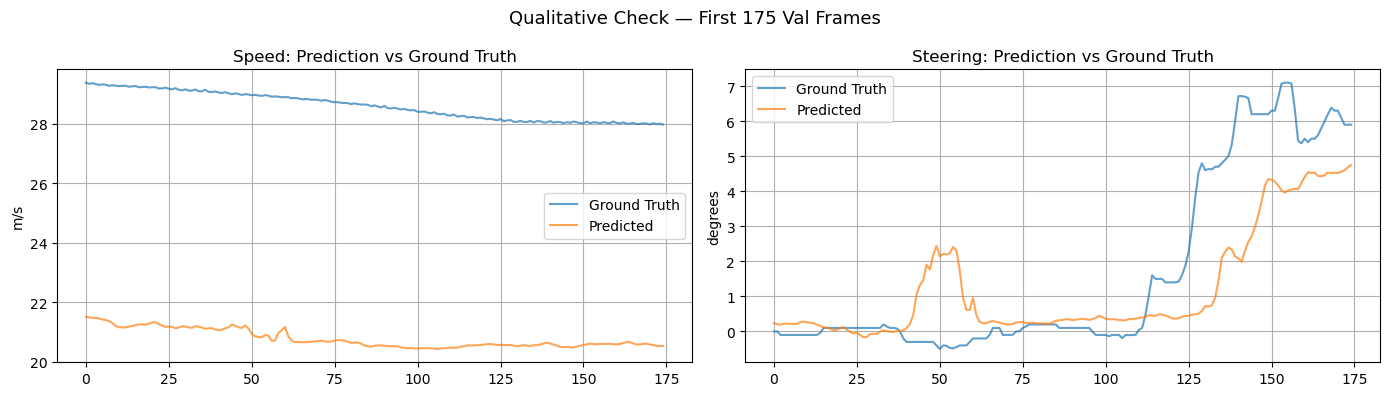

In [15]:
model.load_state_dict(torch.load(SAVE_DIR / 'baseline_best.pth', map_location=device))
model.eval()

pred_speeds, gt_speeds, pred_steers, gt_steers = [], [], [], []

with torch.no_grad():
    for i, batch in enumerate(val_loader):
        pred = model(batch['x_frame'].to(device),
                     batch['x_speed'].to(device),
                     batch['x_steer'].to(device)).cpu()
        pred_speeds.extend(pred[:, 0].numpy())
        gt_speeds.extend(batch['y_speed'].numpy())
        pred_steers.extend(pred[:, 1].numpy())
        gt_steers.extend(batch['y_steer'].numpy())
        if len(gt_speeds) >= 175:
            break

n = min(175, len(gt_speeds))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(gt_speeds[:n],   label='Ground Truth', alpha=0.7)
axes[0].plot(pred_speeds[:n], label='Predicted',    alpha=0.7)
axes[0].set_title('Speed: Prediction vs Ground Truth')
axes[0].set_ylabel('m/s'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(gt_steers[:n],   label='Ground Truth', alpha=0.7)
axes[1].plot(pred_steers[:n], label='Predicted',    alpha=0.7)
#axes[1].set_ylim(-1, 7)
axes[1].set_title('Steering: Prediction vs Ground Truth')
axes[1].set_ylabel('degrees'); axes[1].legend(); axes[1].grid(True)

plt.suptitle('Qualitative Check — First 175 Val Frames', fontsize=13)
plt.tight_layout()
plt.show()
